# Flipkart Mobiles Details Web - Scrapping.

## 1: Libraries 

In [27]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import csv


In [28]:
# website to scrap is flipkart and search mobiles:

# https://www.flipkart.com/search?q=mobiles&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off


In [29]:
source_url = "https://www.flipkart.com/search?q=mobiles&as=on&as-show=on&otracker=AS_Query_TrendingAutoSuggest_1_0_na_na_na&otracker1=AS_Query_TrendingAutoSuggest_1_0_na_na_na&as-pos=1&as-type=HISTORY&suggestionId=mobiles&requestId=bead7043-e8d8-413b-9621-8d630de51928https://www.flipkart.com/search?q=mobiles&as=on&as-show=on&otracker=AS_Query_TrendingAutoSuggest_1_0_na_na_na&otracker1=AS_Query_TrendingAutoSuggest_1_0_na_na_na&as-pos=1&as-type=HISTORY&suggestionId=mobiles&requestId=bead7043-e8d8-413b-9621-8d630de51928"


In [30]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}


## User defined function for multiple page scrapping

In [31]:


def scrape_flipkart_mobiles(page_number):
   
    # Construct URL with page parameter
    source_url = f"https://www.flipkart.com/search?q=mobiles&page={page_number}&as=on&as-show=on"
    
    try:
        response = requests.get(source_url, headers=headers, timeout=10)
        response.raise_for_status()
        
        parse = BeautifulSoup(response.content, "html.parser")
        
        # Extract titles
        title = parse.find_all('div', class_='RG5Slk')
        title = [item.text for item in title]
        
        # Extract prices
        price = parse.find_all('div', class_='hZ3P6w DeU9vF')
        price = [item.text for item in price]
        
        # Extract ratings
        rating = parse.find_all('div', class_='MKiFS6')
        rating = [item.text for item in rating]
        
        # Extract specifications
        products = parse.find_all('div', class_='col col-7-12')
        rows = []
        
        for product in products:
            specs = product.find('ul', class_='HwRTzP')
            
            if specs:
                spec_list = [li.get_text(strip=True) for li in specs.find_all("li")]
                
                rows.append({
                    'RAM': spec_list[0] if len(spec_list) > 0 else "",
                    'Display': spec_list[1] if len(spec_list) > 1 else "",
                    'Camera': spec_list[2] if len(spec_list) > 2 else "",
                    'Battery': spec_list[3] if len(spec_list) > 3 else "",
                    'Warranty': spec_list[5] if len(spec_list) > 5 else "",
                })
        
        # Combine all data
        data = {
            'title': title,
            'price': price,
            'rating': rating,
            'specs': rows
        }
        
        print(f"✓ Page {page_number} scraped successfully")
        return data
        
    except Exception as e:
        print(f"✗ Error scraping page {page_number}: {e}")
        return None


## to save file to flipkart_mobile.csv

In [32]:
def save_to_csv(all_data, filename='flipkart_mobiles.csv'):
   
    with open(filename, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Title', 'Price', 'Rating', 'RAM', 'Display', 'Camera', 'Battery', 'Warranty'])
        
        for page_data in all_data:
            if page_data:
                for t, p, r, spec in zip(page_data['title'], page_data['price'], page_data['rating'], page_data['specs']):
                    writer.writerow([
                        t, p, r, 
                        spec["RAM"], spec["Display"], spec["Camera"],
                        spec["Battery"], spec["Warranty"]
                    ])
    
    print(f"✓ Data saved to {filename}")



## Main execution - Scrape multiple pages

In [33]:

if __name__ == "__main__":
    all_scraped_data = []
    num_pages = 50  # Change this to scrape more/fewer pages
    
    for page in range(1, num_pages + 1):
        data = scrape_flipkart_mobiles(page)
        if data:
            all_scraped_data.append(data)
        time.sleep(2)  # Wait 2 seconds between requests to avoid blocking
    
    # Save all data to CSV
    save_to_csv(all_scraped_data)
    
    print(f"\n✓ Scraping complete! Total pages scraped: {len(all_scraped_data)}")


✓ Page 1 scraped successfully
✓ Page 2 scraped successfully
✓ Page 3 scraped successfully
✓ Page 4 scraped successfully
✓ Page 5 scraped successfully
✓ Page 6 scraped successfully
✓ Page 7 scraped successfully
✓ Page 8 scraped successfully
✓ Page 9 scraped successfully
✓ Page 10 scraped successfully
✓ Page 11 scraped successfully
✓ Page 12 scraped successfully
✓ Page 13 scraped successfully
✓ Page 14 scraped successfully
✓ Page 15 scraped successfully
✓ Page 16 scraped successfully
✓ Page 17 scraped successfully
✓ Page 18 scraped successfully
✓ Page 19 scraped successfully
✓ Page 20 scraped successfully
✓ Page 21 scraped successfully
✓ Page 22 scraped successfully
✓ Page 23 scraped successfully
✓ Page 24 scraped successfully
✓ Page 25 scraped successfully
✓ Page 26 scraped successfully
✓ Page 27 scraped successfully
✓ Page 28 scraped successfully
✓ Page 29 scraped successfully
✓ Page 30 scraped successfully
✓ Page 31 scraped successfully
✓ Page 32 scraped successfully
✓ Page 33 scraped

In [39]:
# %pip install --upgrade pip
# %pip install textblob nltk vaderSentiment matplotlib seaborn

import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download required NLTK data
nltk.download('vader_lexicon')
nltk.download('punkt')


[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


False

In [40]:
def analyze_sentiment_from_csv(csv_filename='flipkart_mobiles.csv'):
    """
    Analyze sentiment of mobile products based on ratings
    
    Args:
        csv_filename (str): Path to the CSV file with scraped data
    
    Returns:
        DataFrame: Enhanced dataframe with sentiment analysis
    """
    # Read CSV file
    df = pd.read_csv(csv_filename)
    
    # Initialize sentiment analyzer
    sia = SentimentIntensityAnalyzer()
    
    # Convert Rating to numeric (remove non-numeric characters)
    df['Rating_Numeric'] = pd.to_numeric(df['Rating'], errors='coerce')
    
    # Classify sentiment based on rating
    def classify_sentiment(rating):
        if pd.isna(rating):
            return 'Unknown'
        elif rating >= 4.0:
            return 'Positive'
        elif rating >= 3.0:
            return 'Neutral'
        else:
            return 'Negative'
    
    df['Sentiment'] = df['Rating_Numeric'].apply(classify_sentiment)
    
    # Calculate sentiment scores for title
    def get_sentiment_score(text):
        if pd.isna(text):
            return 0
        scores = sia.polarity_scores(str(text))
        return scores['compound']
    
    df['Title_Sentiment_Score'] = df['Title'].apply(get_sentiment_score)
    
    return df



In [41]:

def visualize_sentiment_analysis(df):
    """
    Create visualizations for sentiment analysis
    
    Args:
        df (DataFrame): Dataframe with sentiment data
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Sentiment Distribution
    sentiment_counts = df['Sentiment'].value_counts()
    axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'orange', 'red'])
    axes[0, 0].set_title('Sentiment Distribution')
    axes[0, 0].set_xlabel('Sentiment')
    axes[0, 0].set_ylabel('Count')
    
    # 2. Rating Distribution
    axes[0, 1].hist(df['Rating_Numeric'].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Rating Distribution')
    axes[0, 1].set_xlabel('Rating')
    axes[0, 1].set_ylabel('Frequency')
    
    # 3. Sentiment vs Price
    sentiment_price = df.groupby('Sentiment')['Price'].apply(lambda x: x.str.replace('₹', '').str.replace(',', '').astype(float).mean())
    axes[1, 0].bar(sentiment_price.index, sentiment_price.values, color=['green', 'orange', 'red'])
    axes[1, 0].set_title('Average Price by Sentiment')
    axes[1, 0].set_xlabel('Sentiment')
    axes[1, 0].set_ylabel('Average Price (₹)')
    
    # 4. Sentiment Pie Chart
    colors = {'Positive': 'green', 'Neutral': 'orange', 'Negative': 'red', 'Unknown': 'gray'}
    colors_list = [colors.get(sentiment, 'gray') for sentiment in sentiment_counts.index]
    axes[1, 1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors_list)
    axes[1, 1].set_title('Sentiment Percentage')
    
    plt.tight_layout()
    plt.show()





In [42]:

def generate_sentiment_report(df):
    """
    Generate a detailed sentiment analysis report
    
    Args:
        df (DataFrame): Dataframe with sentiment data
    """
    print("\n" + "="*60)
    print("SENTIMENT ANALYSIS REPORT")
    print("="*60)
    
    print(f"\nTotal Products Analyzed: {len(df)}")
    print(f"\nSentiment Summary:")
    print(df['Sentiment'].value_counts())
    
    print(f"\nRating Statistics:")
    print(f"  Average Rating: {df['Rating_Numeric'].mean():.2f}")
    print(f"  Median Rating: {df['Rating_Numeric'].median():.2f}")
    print(f"  Min Rating: {df['Rating_Numeric'].min():.2f}")
    print(f"  Max Rating: {df['Rating_Numeric'].max():.2f}")
    
    print(f"\nSentiment Breakdown:")
    for sentiment in ['Positive', 'Neutral', 'Negative', 'Unknown']:
        count = len(df[df['Sentiment'] == sentiment])
        percentage = (count / len(df)) * 100
        print(f"  {sentiment}: {count} ({percentage:.1f}%)")
    
    print(f"\nTop 5 Highest Rated Products:")
    top_products = df.nlargest(5, 'Rating_Numeric')[['Title', 'Rating', 'Price']]
    for idx, row in top_products.iterrows():
        print(f"  • {row['Title'][:50]}... - Rating: {row['Rating']}, Price: {row['Price']}")
    
    print("\n" + "="*60)


                                              Title  Rating Sentiment  \
0          Infinix SMART 20 (Cloudline Blue, 64 GB)     4.0  Positive   
1                       POCO X8 Pro (Black, 256 GB)     4.4  Positive   
2                 Samsung Galaxy F07 (Green, 64 GB)     4.3  Positive   
3  Samsung Galaxy F70e 5G (Limelight Green, 128 GB)     4.2  Positive   
4            POCO X8 Pro (Iron man edition, 256 GB)     4.4  Positive   
5                       POCO X8 Pro (Black, 256 GB)     4.3  Positive   
6                 vivo T5x 5G (Cyber Green, 256 GB)     4.4  Positive   
7                 HMD Vibe2 5G (Peach Pink, 128 GB)     4.6  Positive   
8           realme P4 Lite 5G (Mosaic Blue, 128 GB)     4.3  Positive   
9                       Ai+ Pulse 2 (Purple, 64 GB)     4.3  Positive   

   Title_Sentiment_Score  
0                 0.5319  
1                 0.0000  
2                 0.0000  
3                 0.0000  
4                 0.0000  
5                 0.0000  
6      

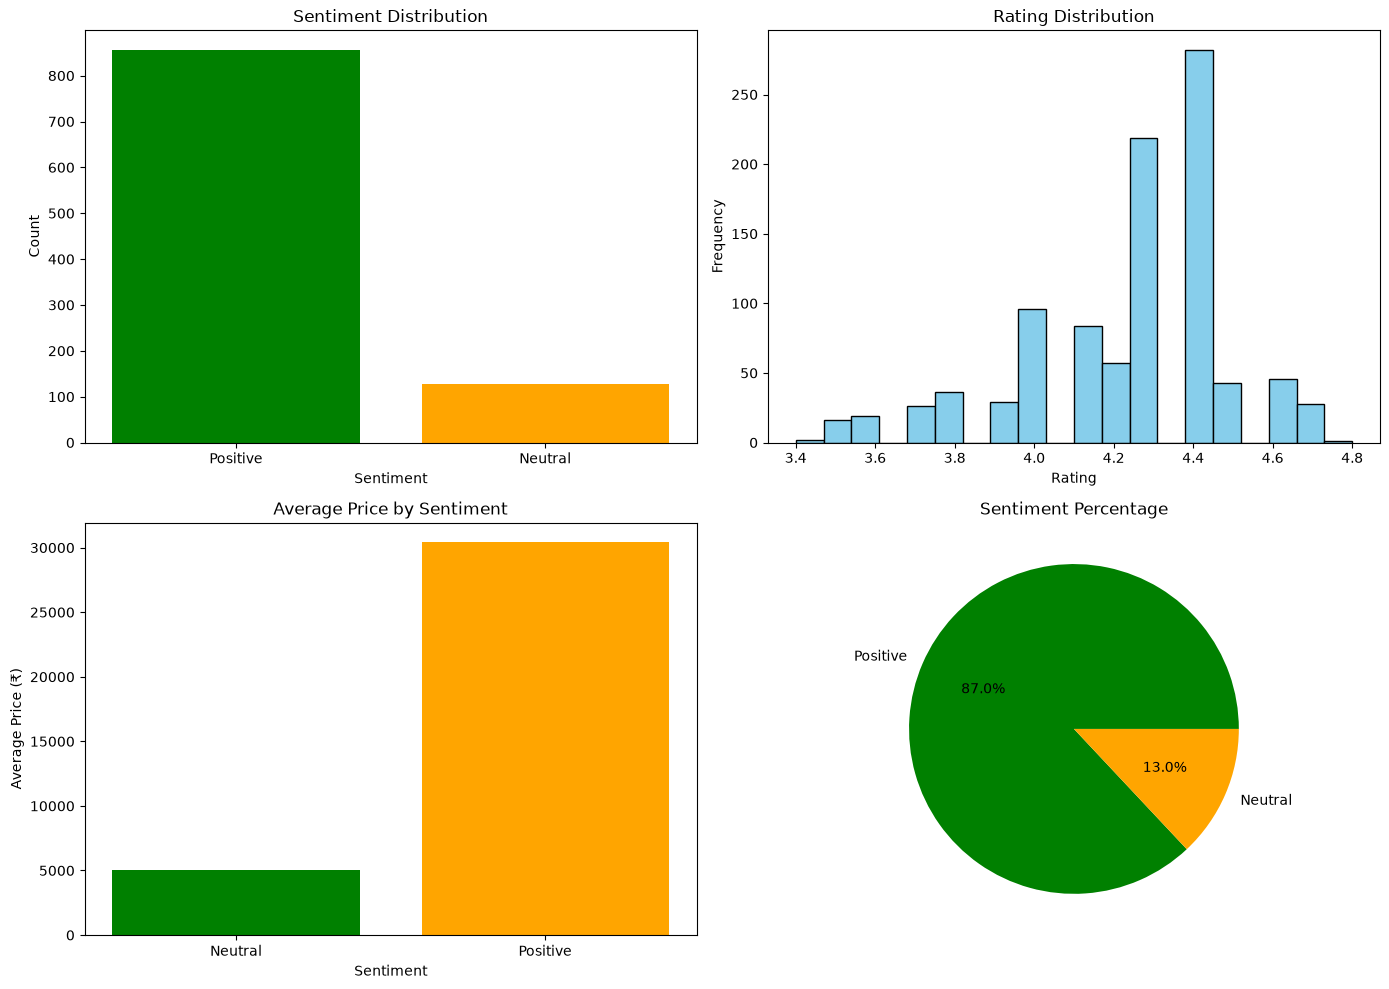


✓ Sentiment analysis complete! Results saved to 'flipkart_mobiles_with_sentiment.csv'


In [38]:
# Main execution - Run sentiment analysis
if __name__ == "__main__":
    # Perform sentiment analysis
    df_sentiment = analyze_sentiment_from_csv('flipkart_mobiles.csv')
    
    # Display first few rows
    print(df_sentiment[['Title', 'Rating', 'Sentiment', 'Title_Sentiment_Score']].head(10))
    
    # Generate report
    generate_sentiment_report(df_sentiment)
    
    # Create visualizations
    visualize_sentiment_analysis(df_sentiment)
    
    # Save enhanced CSV with sentiment analysis
    df_sentiment.to_csv('flipkart_mobiles_with_sentiment.csv', index=False)
    print("\n✓ Sentiment analysis complete! Results saved to 'flipkart_mobiles_with_sentiment.csv'")
